# Setting the level, not just building the thing

A construct that works is not the same as a construct that works *at the level
you wanted*. Too little product and the pathway does not carry flux; too much and
the host stops growing, or the cells that lost the plasmid take over the culture.

This notebook covers the knobs: how fast the mRNA is made, how fast it is
translated, how well the codons match the tRNA pool, where in the chromosome the
whole thing sits, and what it costs the host — with the cost expressed as a
growth rate rather than as a warning.

Each section is also an argument about **which knob is worth turning**, because
they do not have comparable authority. Two of them are much weaker than they look.

In [1]:
import omicverse as ov
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — Transcription: a graded promoter series

Tuning a pathway needs a *set* that spans a range, not one part that scores well.
`promoter_library` searches −35/−10 variants and returns members binned across a
requested span.

In [2]:
promoters = ov.synbio.promoter_library(n=6, target_range=(0.05, 1.0))
print(promoters)
print(promoters.to_frame().round(3).to_string())

ExpressionLibrary(promoter, 6 parts, 0.667–1 (2x), coverage 14%)


                                          sequence  predicted
0  GCTAGCTTAACGGTTAAAGTTGTTAATATGAGAATGCTAGCACTAGT      0.667
1  GCTAGCTTGACGTGCAACTCTCGGTGTTGCATGATGCTAGCACTAGT      0.733
2  GCTAGCTTGACATAGCTATAGGTCTGTATTAGAAAGCTAGCACTAGT      0.800
3  GCTAGCATGACACCCTACACTGCTGTACTTATATTGCTAGCACTAGT      0.833
4  GCTAGCTTGACATATGCGGCCGGGCTCCTTAGAATGCTAGCACTAGT      0.900
5  GCTAGCTTGACAGGAACTCTCATTAAGCGTATAATGCTAGCACTAGT      1.000


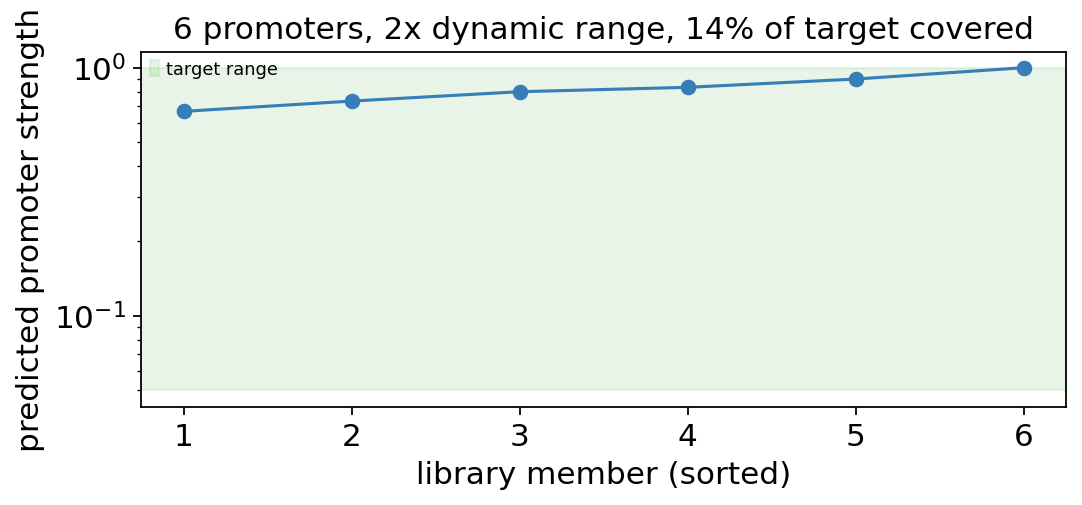

In [3]:
ov.synbio.plot_expression_library(promoters)
None

**Read the achieved span against the requested one before anything else.** The
request was 0.05–1.0, a twentyfold range. What came back spans 0.667–1.0 — **2×,
at 14% coverage of the request.** The function reports that rather than
pretending; it is not a bug so much as the scale running out.

`promoter_strength` scores the match to the σ70 consensus, and that scale is
**compressed**: the Anderson series spans about 100-fold in measured RPU while
consensus-match scores across it span under 1.5-fold. There is nowhere for a
graded library to go. Contrast the RBS library in the next section, which reaches
5,653× on the same kind of request.

The measured alternative is in tutorial 07: `fetch_promoter_library` returns
10,898 σ70 variants with real expression. When the level matters, pick parts from
measurements, not from a consensus score.

The measured alternative is in tutorial 07: `fetch_promoter_library` returns
10,898 σ70 variants with real expression, and picking parts from measurements
beats picking them from a consensus score.

## 2 — Translation: a graded RBS series

The same idea for the ribosome binding site, and here the scale is stronger —
`rbs_strength` computes an SD:anti-SD hybridisation energy, an mRNA folding cost,
and a spacing penalty.

In [4]:
cds = ov.synbio.codon_optimize(ov.synbio.reference_protein('gfp'), host='e_coli').sequence
rbs = ov.synbio.rbs_library(cds, n=6, target_range=(1.0, 1000.0))
print(rbs)
print(rbs.to_frame().round(1).to_string())

ExpressionLibrary(rbs, 6 parts, 1.39–7.86e+03 (5653x), coverage 100%)
                                 sequence  predicted
0    TTTAAGAAGGAGATATACATAACAGCTCCCGCCTTC        1.4
1    TTTAAGAAGGAGATATACATTGGCGTCACCATATGT       10.5
2   TTTAAGAAGGAGATATACATAGAAGGTTCGTTGTACC       55.7
3  TTTAAGAAGGAGATATACATCGGAGACGGGTCGCCATG      281.5
4  TTTAAGAAGGAGATATACATAGGAGGGATCGTGGGTAT     1488.0
5      TTTAAGAAGGAGATATACATAGGAGGTTATATAA     7864.9


Nearly a thousand-fold, which is what a pathway-balancing experiment needs.

The spacing term is doing real work. Sweep the distance between the
Shine-Dalgarno core and the start codon and hold everything else fixed:

In [5]:
for spacer in (2, 4, 8, 12, 14):
    utr = 'TTTAAGA' + 'AAGGAGG' + 'A' * spacer
    result = ov.synbio.rbs_strength(utr + cds[:60], start=len(utr))
    print(f'  SD-to-AUG {spacer:2d} nt  spacing penalty {result.dG_spacing:+5.2f} '
          f'kcal/mol  rate {result.initiation_rate:9.1f}')

  SD-to-AUG  2 nt  spacing penalty +3.60 kcal/mol  rate    2793.8
  SD-to-AUG  4 nt  spacing penalty +1.60 kcal/mol  rate    6871.7
  SD-to-AUG  8 nt  spacing penalty +0.00 kcal/mol  rate   14117.5
  SD-to-AUG 12 nt  spacing penalty +1.60 kcal/mol  rate    6871.7
  SD-to-AUG 14 nt  spacing penalty +3.60 kcal/mol  rate    1242.9


The optimum sits at 8 nt and 2 or 14 nt costs five- to elevenfold, which matches
the sharp published optimum. Without this term the scorer returned **identical
rates for 6, 8, 10 and 12 nt spacers** — so `rbs_library`, whose docstring says
spacing "is searched rather than fixed", was searching a variable its own scorer
could not see.

`method='ostir'` swaps the heuristic for OSTIR, an open reimplementation of the
Salis RBS Calculator, when it is installed.

## 3 — Both together

`predict_expression` multiplies the promoter, the RBS and the codon adaptation
into one relative number.

In [6]:
strong_promoter = promoters.to_frame()['sequence'].iloc[-1]
strong_rbs = rbs.to_frame()['sequence'].iloc[-1]
level = ov.synbio.predict_expression(strong_promoter, strong_rbs + cds)
for key, value in level.items():
    print(f'  {key:22s} {value:,.3f}')

  promoter               1.000
  rbs_rate               7,864.940
  cai                    1.000
  relative_expression    7,864.940


In [7]:
weak = ov.synbio.predict_expression(promoters.to_frame()['sequence'].iloc[0],
                                    rbs.to_frame()['sequence'].iloc[0] + cds)
print('overall  %.1fx' % (level['relative_expression'] / weak['relative_expression']))
print('promoter %.2fx' % (level['promoter'] / weak['promoter']))
print('RBS      %.1fx' % (level['rbs_rate'] / weak['rbs_rate']))

overall  8480.0x
promoter 1.50x
RBS      5653.3x


The RBS term dominates the product by an order of magnitude, because the two
scales have different dynamic ranges — a.u. spanning decades against a
consensus-match fraction bounded in [0, 1]. That is a property of the scoring,
not of biology, and it is the reason to treat this number as a *ranking* and not
as a prediction of protein per cell.

## 4 — Codons: matching the tRNA pool

CAI asks how closely a gene's codons match the usage of highly expressed genes.
tAI asks how well they match the **tRNA pool that decodes them**. When they
disagree, the disagreement is the useful part.

In [8]:
sequences = {'human GAPDH fragment': ov.synbio.GAPDH_CDS,
             'GFP, human codons': ov.synbio.codon_optimize(
                 ov.synbio.reference_protein('gfp'), host='h_sapiens').sequence,
             'an already E. coli-like ORF':
                 'ATGAAACGCATTGCACTGGTTACCGGCGGCAATCGCGGTATTGGCCTGGCAATTGCACGCGCACTGGCA'}
for name, seq in sequences.items():
    tuned = ov.synbio.codon_optimize(seq, host='e_coli').sequence
    print(f'  {name:28s} tAI {ov.synbio.tai(seq).tai:.4f} -> {ov.synbio.tai(tuned).tai:.4f}'
          f'   CAI {ov.synbio.cai(seq):.3f} -> {ov.synbio.cai(tuned):.3f}')

  human GAPDH fragment         tAI 0.2898 -> 0.3361   CAI 0.664 -> 0.984
  GFP, human codons            tAI 0.3219 -> 0.3397   CAI 0.664 -> 0.994
  an already E. coli-like ORF  tAI 0.4342 -> 0.3861   CAI 0.861 -> 0.946


CAI rises every time — it is what the optimiser maximises. **tAI does not move in
a consistent direction.** The two sequences that started poorly adapted improve;
the one that was already *E. coli*-like gets **worse**.

That is not a bug in either index. They disagree on the four-fold degenerate
families: for alanine, glycine and valine *E. coli* carries more of the tRNA that
reads the A-ending codon than of the one Ikemura found preferred in highly
expressed genes. So a codon-usage optimiser walking away from an already
tRNA-adapted sequence has somewhere worse to go.

The practical reading: CAI optimisation is a reliable way to raise CAI and an
unreliable way to raise translation rate. Check tAI afterwards rather than
assuming it followed.

The tRNA table this rests on was recounted from the MG1655 annotation — all 86
tRNA genes located and their anticodons read out of the anticodon loop — after
the shipped table turned out to place the copy number on the wrong anticodon for
14 of the 20 amino acids. `check_trna_table()` is exported so it cannot rot again.

In [9]:
from omicverse.synbio._tuning import check_trna_table
print('tRNA table check:', check_trna_table() or 'passes')
print('lysine anticodons:', {k: v for k, v in
      ov.synbio.TRNA_COPY_NUMBERS['e_coli'].items() if k in ('TTT', 'CTT')})

tRNA table check: passes
lysine anticodons: {'TTT': 6}


`TTT: 6` — the six *lysT/V/W/Y/Z/Q* genes with anticodon UUU. There is no
CUU-anticodon tRNA in *E. coli*, and the previous table gave that non-existent
species all six copies.

## 5 — Where to put it

Plasmid or chromosome, and if chromosome, where. Expression across the tabulated
sites spans 0.4× to 2.6× **relative to the neutral attTn7 landing site** — not
relative to a plasmid.

In [10]:
for site in ov.synbio.integration_sites(target_expression=2.5)[:4]:
    print(f'  {site.name:20s} {site.relative_expression:4.1f}x  score {site.score:+.3f}  '
          f'{"essential nearby" if site.essential_nearby else ""}')

  near oriC             2.6x  score +0.693  essential nearby
  attB(HK022)           1.2x  score -0.059  
  attB(lambda)          1.1x  score -0.184  
  attTn7 (glmS)         1.0x  score -0.322  


Asking for 2.5× returns the 2.6× site first. It did not before: the score
subtracted `|log2(expr/target)|/3` for missing the target and a flat 0.4 for
essentiality, so a 2.1-fold miss cost less than being near an essential gene, and
the near-perfect site came third.

`plot_integration_sites` puts the whole catalogue on one axis, with the
essential-gene flag marked, so the trade-off between the level you asked for and
the risk you take is visible rather than buried in a score.

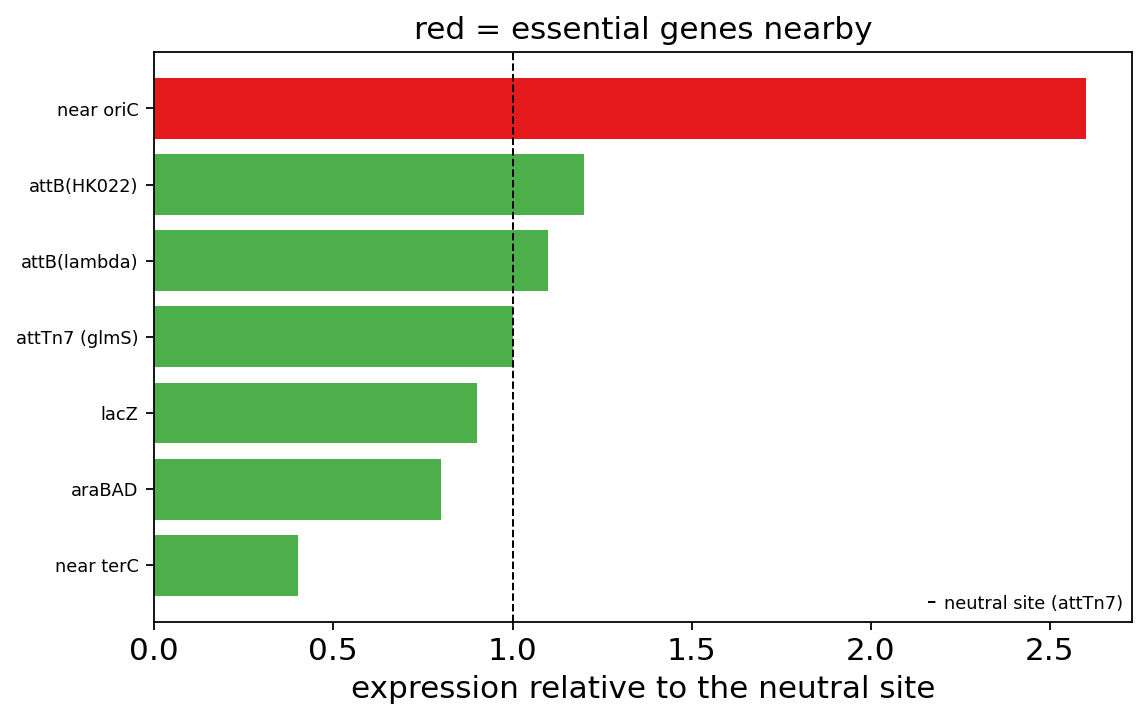

In [11]:
ov.synbio.plot_integration_sites(ov.synbio.integration_sites(target_expression=2.5))
None

### The table checks itself

Site expression is usually argued from gene dosage — loci near *oriC* are present
in more copies during fast growth. That argument can be checked.

In [12]:
from omicverse.synbio._tuning import replichore_fraction, check_integration_sites
for site in ov.synbio.ECOLI_INTEGRATION_SITES[:4]:
    print(f"  {site['name']:20s} {replichore_fraction(site['position']):.3f} of the "
          f"replichore from oriC, {site['relative_expression']}x")

  attTn7 (glmS)        0.005 of the replichore from oriC, 1.0x
  attB(HK022)          0.782 of the replichore from oriC, 1.2x
  attB(lambda)         0.656 of the replichore from oriC, 1.1x
  near oriC            0.000 of the replichore from oriC, 2.6x


In [13]:
for name, reason in check_integration_sites().items():
    print(f'{name}: {reason}')

attTn7 (glmS): 与 'near oriC' 的复制叉位置几乎相同(replichore 分数 0.005 vs 0.000),相对表达却差 2.6 倍 —— 这个差异不可能来自基因剂量。


**The shipped table fails its own check**, and it is left failing rather than
quietly adjusted. `attTn7 (glmS)` and `near oriC` sit 12 kb apart — 0.005 and
0.000 of the way down the replichore — and are assigned 1.0× and 2.6×. No dosage
gradient exists over 12 kb of a 4.64 Mb genome, so at most one of those numbers
can be right for that reason.

What *was* fixed is verifiable: the glmS coordinate. It read 3,925,000, which is
744 bp from oriC; the real *glmS* spans 3,911,839–3,913,668 in NC_000913.3, so
attTn7 sits at about 3,913,700. Correcting it does not rescue the expression
values, and inventing values that would pass the check would be worse than
shipping a check that fails.

The transferable point: the standard "neutral" landing site is **oriC-proximal**,
so expression measured there is not a dosage-neutral baseline.

## 6 — What it costs the host

Burden as a growth rate, through the proteome budget.

In [14]:
model = ov.synbio.load_gem('textbook')
burden = ov.synbio.plasmid_burden(model, copy_number=100, expressed_protein_fraction=0.30)
print(burden)
print({k: round(v, 4) for k, v in burden.components.items()})

INFO:cobra.io.web.load:Attempting to fetch 'textbook' from the Cobrapy repository.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


...

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


BurdenEstimate(25.8% growth loss, 0.8739 -> 0.6480 /h, will be selected against)
{'protein': 0.3, 'dna': 0.0054, 'protein_share_of_cost': 0.9824, 'budget_left': 0.0917}


Now the part that decides how to read any burden sweep: which input is driving it.

In [15]:
for copies in (1, 20, 100, 500):
    b = ov.synbio.plasmid_burden(model, copy_number=copies, expressed_protein_fraction=0.30)
    print(f'  {copies:>4} copies, protein fixed at 30%  ->  burden {b.burden:6.2%}')

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


...

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


   500 copies, protein fixed at 30%  ->  burden 28.31%


In [16]:
for fraction in (0.02, 0.10, 0.30, 0.50):
    b = ov.synbio.plasmid_burden(model, copy_number=20, expressed_protein_fraction=fraction)
    print(f'  {fraction:>5.0%} protein, copies fixed at 20  ->  burden {b.burden:6.2%}')

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


...

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


    50% protein, copies fixed at 20  ->  burden 48.26%


A **500-fold** change in copy number moves the burden by 3 percentage points. A
change in expressed-protein fraction moves it across the whole range. The
function is dominated by `expressed_protein_fraction`, and the DNA term is a
coarse constant.

So a sweep that raises copy number and protein fraction *together* — the natural
way to write a demo — produces a curve that reads as a copy-number effect and is
not one. The function now says so in its notes rather than leaving it to be
discovered.

## 7 — RNA-level devices and diagnostics

A toehold switch is a specific device where `rna_inverse_design` is a general
solver.

In [17]:
trigger = 'AUGGUUUACAUGUUCCAAUAUGAUUCC'
switch = ov.synbio.toehold_switch(trigger)
print(switch)
print('toehold', switch.toehold, '| stem', switch.stem, '| AUG at', switch.start_codon_position)

ToeholdSwitch(toehold 12 nt, stem 9 nt, ON/OFF ~7x)
toehold GGAAUCAUAUUG | stem GAACAUGUA | AUG at 41


In [18]:
rbs_start = switch.switch_rna.find(switch.rbs)
opening = ov.synbio.rna_accessibility(switch.switch_rna, rbs_start, rbs_start + len(switch.rbs))
print('trigger:toehold ΔG %.2f kcal/mol' % ov.synbio.rna_duplex(trigger, switch.toehold).energy)
print('cost of exposing the RBS while folded: %.2f kcal/mol' % opening)
print('estimated ON/OFF: %.1fx' % switch.on_off_estimate)

trigger:toehold ΔG -14.90 kcal/mol
cost of exposing the RBS while folded: 0.74 kcal/mol
estimated ON/OFF: 7.5x


`rna_duplex` gives the trigger-toehold hybridisation energy — how strongly the
switch is opened — and `rna_accessibility` gives the cost of exposing the RBS in
the folded switch, which is what keeps it closed without a trigger. A switch
whose RBS is already accessible has no OFF state; a toehold that binds too weakly
has no ON state. Both numbers have to be read, and they trade against each other.

## What to carry away

**The knobs are not equally trustworthy.** The RBS scale spans decades and now
responds to spacing. The promoter scale is a consensus-match fraction that
compresses a 100-fold measured range into under 1.5-fold — use measured parts
(tutorial 07) when the level matters. `predict_expression` multiplies the two, so
its product inherits the weaker one and should be read as a ranking.

**Two tables here carry checks that can fail**, and one of them does.
`check_trna_table()` passes after the anticodon assignments were recounted from
the genome. `check_integration_sites()` fails, on purpose: two sites 12 kb apart
are assigned a 2.6-fold expression difference that gene dosage cannot produce.
The coordinate error behind it was fixable from the annotation; the expression
values were not, and a check that fails is more useful than numbers that quietly
do not add up.

**Burden is about protein, not plasmid.** 500× the copy number costs 3 points of
growth; the expressed-protein fraction costs everything else.